In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [2]:
df=pd.read_csv("amazon.csv",encoding="iso-8859-1",parse_dates=['date'])

In [3]:
df

,year,state,month,number,date
0,1998,Acre,Janeiro,0.0,1998-01-01
1,1999,Acre,Janeiro,0.0,1999-01-01
2,2000,Acre,Janeiro,0.0,2000-01-01
3,2001,Acre,Janeiro,0.0,2001-01-01
4,2002,Acre,Janeiro,0.0,2002-01-01
...,...,...,...,...,...
6449,2012,Tocantins,Dezembro,128.0,2012-01-01
6450,2013,Tocantins,Dezembro,85.0,2013-01-01
6451,2014,Tocantins,Dezembro,223.0,2014-01-01
6452,2015,Tocantins,Dezembro,373.0,2015-01-01


### 1. Check top 10 rows

In [4]:
df.head(10)

,year,state,month,number,date
0,1998,Acre,Janeiro,0.0,1998-01-01
1,1999,Acre,Janeiro,0.0,1999-01-01
2,2000,Acre,Janeiro,0.0,2000-01-01
3,2001,Acre,Janeiro,0.0,2001-01-01
4,2002,Acre,Janeiro,0.0,2002-01-01
5,2003,Acre,Janeiro,10.0,2003-01-01
6,2004,Acre,Janeiro,0.0,2004-01-01
7,2005,Acre,Janeiro,12.0,2005-01-01
8,2006,Acre,Janeiro,4.0,2006-01-01
9,2007,Acre,Janeiro,0.0,2007-01-01


### 2. Check last 10 rows

In [5]:
df.tail(10)

,year,state,month,number,date
6444,2007,Tocantins,Dezembro,13.0,2007-01-01
6445,2008,Tocantins,Dezembro,7.0,2008-01-01
6446,2009,Tocantins,Dezembro,46.0,2009-01-01
6447,2010,Tocantins,Dezembro,72.0,2010-01-01
6448,2011,Tocantins,Dezembro,105.0,2011-01-01
6449,2012,Tocantins,Dezembro,128.0,2012-01-01
6450,2013,Tocantins,Dezembro,85.0,2013-01-01
6451,2014,Tocantins,Dezembro,223.0,2014-01-01
6452,2015,Tocantins,Dezembro,373.0,2015-01-01
6453,2016,Tocantins,Dezembro,119.0,2016-01-01


### 3. Check Shape of dataset

In [6]:
print("Total number of row is: ",df.shape[0])
print("Total number of column is: ",df.shape[1])

Total number of row is:  6454
Total number of column is:  5


### 4.Check info of dataset

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6454 entries, 0 to 6453
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   year    6454 non-null   int64         
 1   state   6454 non-null   object        
 2   month   6454 non-null   object        
 3   number  6454 non-null   float64       
 4   date    6454 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(1), object(2)
memory usage: 252.2+ KB


### 5. Check Is any null value present?

In [8]:
df.isnull().sum()

year      0
state     0
month     0
number    0
date      0
dtype: int64

### 6. Check Duplicate value and drop them

In [9]:
dup=df.duplicated().any()
dup

In [10]:
data=df.drop_duplicates()
data

### 7. Get Overall Statistics About The Dataframe

In [11]:
df.describe()

,year,number,date
count,6454.000000,6454.000000,6454
mean,2007.461729,108.293163,2007-06-18 18:28:53.622559488
min,1998.000000,0.000000,1998-01-01 00:00:00
25%,2002.000000,3.000000,2002-01-01 00:00:00
50%,2007.000000,24.000000,2007-01-01 00:00:00
75%,2012.000000,113.000000,2012-01-01 00:00:00
max,2017.000000,998.000000,2017-01-01 00:00:00
std,5.746654,190.812242,NaN


In [12]:
df.describe(include='all')

,year,state,month,number,date
count,6454.000000,6454,6454,6454.000000,6454
unique,NaN,23,12,NaN,NaN
top,NaN,Rio,Janeiro,NaN,NaN
freq,NaN,717,541,NaN,NaN
mean,2007.461729,NaN,NaN,108.293163,2007-06-18 18:28:53.622559488
min,1998.000000,NaN,NaN,0.000000,1998-01-01 00:00:00
25%,2002.000000,NaN,NaN,3.000000,2002-01-01 00:00:00
50%,2007.000000,NaN,NaN,24.000000,2007-01-01 00:00:00
75%,2012.000000,NaN,NaN,113.000000,2012-01-01 00:00:00
max,2017.000000,NaN,NaN,998.000000,2017-01-01 00:00:00


### 8. Replace Month Names with English Equivalents

In [14]:
df['month_new'] = df['month'].map({
    'Janeiro':  'jan',
    'Fevereiro':'feb',
    'Março':    'march',
    'Abril':    'april',
    'Maio':     'may',
    'Junho':    'jun',
    'Julho':    'july',
    'Agosto':   'august',
    'Setembro': 'sep',
    'Outubro':  'oct',
    'Novembro': 'nov',
    'Dezembro': 'dec'
})

In [15]:
df.head(1)

,year,state,month,number,date,month_new
0,1998,Acre,Janeiro,0.0,1998-01-01,jan


### 9. Find Names of States Recording Fires in august

In [24]:
df[df['month_new']=='august']['state'].unique()

array(['Acre', 'Alagoas', 'Amapa', 'Amazonas', 'Bahia', 'Ceara',
       'Distrito Federal', 'Espirito Santo', 'Goias', 'Maranhao',
       'Mato Grosso', 'Minas Gerais', 'Pará', 'Paraiba', 'Pernambuco',
       'Piau', 'Rio', 'Rondonia', 'Roraima', 'Santa Catarina',
       'Sao Paulo', 'Sergipe', 'Tocantins'], dtype=object)

### 10. In Which Year Maximum Number of Forest Fires Was Reported?

In [18]:
data= df.groupby('year') ['number'].sum().reset_index()
data

,year,number
0,1998,20013.971
1,1999,26882.821
2,2000,27351.251
3,2001,29071.612
4,2002,37390.600
5,2003,42760.674
6,2004,38453.163
7,2005,35004.965
8,2006,33832.161
9,2007,33037.413


<Axes: xlabel='year', ylabel='number'>

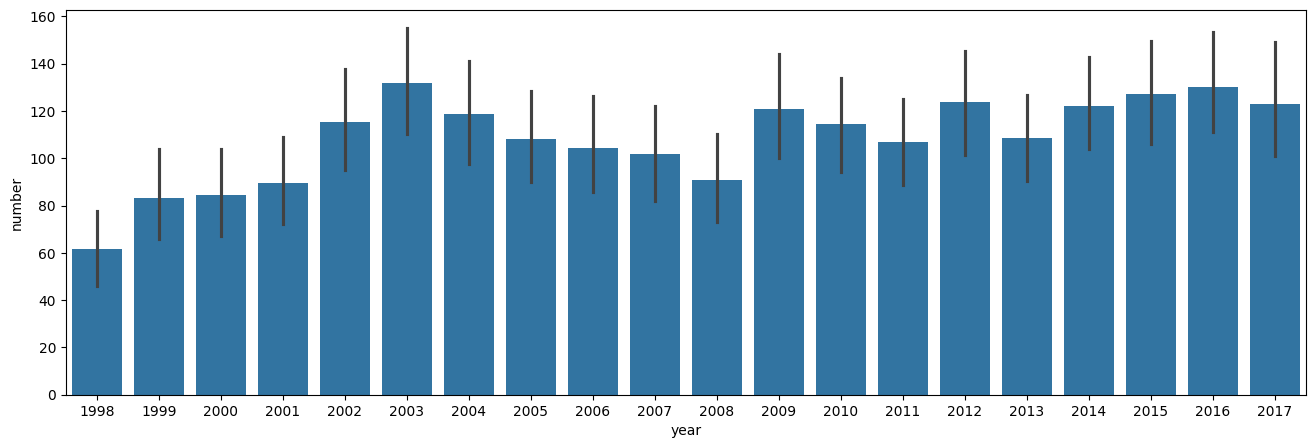

In [20]:
plt.figure(figsize=(16,5))
sns.barplot(x='year',y='number',data=df)

### 11. Find Total Fires Registered in Amazonas

In [22]:
df[df['state']=='Amazonas'] ['number'].sum()

np.float64(30650.129)

### 12.In Which Month Maximum Number of Forest Fires Were Reported?

In [25]:
data= df.groupby('month_new') ['number'].sum().reset_index()
data

,month_new,number
0,april,28188.770
1,august,88050.435
2,dec,57535.480
3,feb,30848.050
4,jan,47747.844
5,july,92326.113
6,jun,56010.675
7,march,30717.405
8,may,34731.363
9,nov,85508.054


<Axes: xlabel='month_new', ylabel='number'>

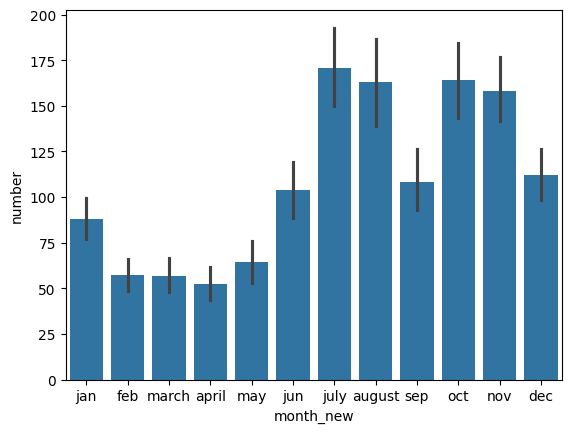

In [26]:
sns.barplot(x='month_new',y='number',data=df)